In [1]:
import pandas as pd
import numpy as np
import joblib

import matplotlib.pyplot as plt

from sklearn.metrics import (
    mean_absolute_error,
    mean_squared_error,
    r2_score
)

In [2]:
# loading the trained model

model = joblib.load("../models/best_model.pkl")
print("Model loaded successfully!")

Model loaded successfully!


In [3]:
# loading the unseen data

data = pd.read_csv("../data/processed/master_dataset.csv")
data.head()

,Driver,Team,LapNumber,Compound,TyreLife,Stint,Position,TrackStatus,LapTimeSeconds
0,VER,Red Bull Racing,1.0,SOFT,4.0,1.0,2.0,1.0,83.186
1,VER,Red Bull Racing,2.0,SOFT,5.0,1.0,2.0,1.0,79.871
2,VER,Red Bull Racing,3.0,SOFT,6.0,1.0,1.0,1.0,79.364
3,VER,Red Bull Racing,4.0,SOFT,7.0,1.0,1.0,1.0,80.766
4,VER,Red Bull Racing,5.0,SOFT,8.0,1.0,1.0,1.0,80.827


In [4]:
# preparing the feature

features = [
    "TyreLife",
    "Compound",
    "Driver",
    "Team",
    "Stint",
    "TrackStatus",
    "Position"
]

target = "LapTimeSeconds"

X = pd.get_dummies(data[features], drop_first=True)
y = data[target]

In [5]:
# aligning the columns with training

expected_columns = model.feature_names_in_
X = X.reindex(columns=expected_columns, fill_value=0)

In [ ]:
# prediction

predictions = model.predict(X)
results = data.copy()
results["PredictedLapTime"] = predictions

results[
    [
        "Driver",
        "Compound",
        "TyreLife",
        "LapTimeSeconds",
        "PredictedLapTime"
    ]
].head(10)

,Driver,Compound,TyreLife,LapTimeSeconds,PredictedLapTime
0,VER,SOFT,4.0,83.186,99.066768
1,VER,SOFT,5.0,79.871,99.326248
2,VER,SOFT,6.0,79.364,99.001381
3,VER,SOFT,7.0,80.766,99.001381
4,VER,SOFT,8.0,80.827,98.935621
5,VER,SOFT,9.0,80.876,98.935621
6,VER,SOFT,10.0,80.973,99.070371
7,VER,SOFT,11.0,80.989,99.214331
8,VER,SOFT,12.0,81.042,99.343531
9,VER,SOFT,13.0,81.003,99.343531


In [ ]:
# evalution

mae = mean_absolute_error(y, predictions)
rmse = np.sqrt(mean_squared_error(y, predictions))
r2 = r2_score(y, predictions)

print(f"MAE  : {mae:.3f}")
print(f"RMSE : {rmse:.3f}")
print(f"R²   : {r2:.3f}")

MAE  : 9.584
RMSE : 11.854
R²   : -0.675


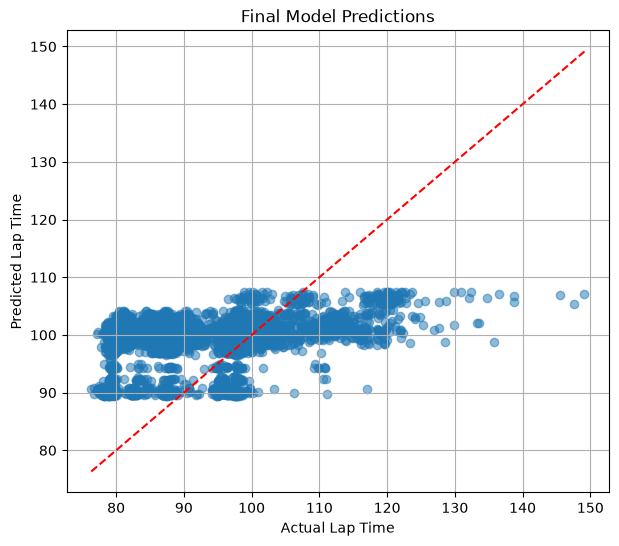

In [8]:
# acutal vs predicted

plt.figure(figsize=(7,6))
plt.scatter(
    y,
    predictions,
    alpha=0.5
)
plt.plot(
    [y.min(), y.max()],
    [y.min(), y.max()],
    "r--"
)

plt.xlabel("Actual Lap Time")
plt.ylabel("Predicted Lap Time")
plt.title("Final Model Predictions")

plt.grid(True)

plt.show()

In [9]:
# sample predictions

comparison = pd.DataFrame({
    "Actual": y,
    "Predicted": predictions
})

comparison["Error"] = (
    comparison["Actual"] -
    comparison["Predicted"]
)

comparison.head(15)

,Actual,Predicted,Error
0,83.186,99.066768,-15.880768
1,79.871,99.326248,-19.455248
2,79.364,99.001381,-19.637381
3,80.766,99.001381,-18.235381
4,80.827,98.935621,-18.108621
5,80.876,98.935621,-18.059621
6,80.973,99.070371,-18.097371
7,80.989,99.214331,-18.225331
8,81.042,99.343531,-18.301531
9,81.003,99.343531,-18.340531


In [10]:
# saving the predictions

results.to_csv(
    "../outputs/final_predictions.csv",
    index=False
)

print("Predictions saved successfully!")

Predictions saved successfully!


In [11]:
# final summary

print("=" * 60)
print("Formula 1 Tire Degradation Prediction Pipeline")
print("=" * 60)

print("✓ Dataset Loaded")
print("✓ Features Prepared")
print("✓ Best Model Loaded")
print("✓ Lap Times Predicted")
print("✓ Performance Evaluated")
print("✓ Predictions Saved")

print("=" * 60)
print("Project Completed Successfully!")
print("=" * 60)

Formula 1 Tire Degradation Prediction Pipeline
✓ Dataset Loaded
✓ Features Prepared
✓ Best Model Loaded
✓ Lap Times Predicted
✓ Performance Evaluated
✓ Predictions Saved
Project Completed Successfully!
